# Logistic Regression — sigmoid, log loss, gradient descent, decision boundary

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import copy, math

## Dataset — Tumour Classification

Two features: tumour size (X0) and patient age (X1).
Binary target: 1 = malignant, 0 = benign.
Goal: learn a decision boundary that separates the two classes.

In [101]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])         

## Visualise Training Data

Plot malignant and benign examples on a 2D feature space.
A good model should find a line that separates the two groups.

Text(0, 0.5, '$x_1$')

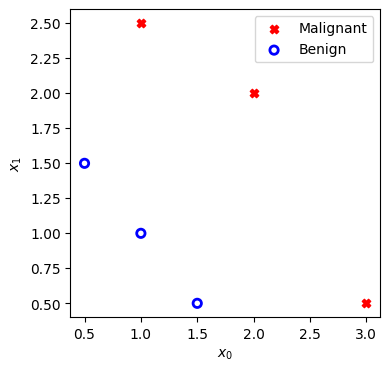

In [ ]:
def plot_data(X, y, ax):
    pos = y==1
    neg = y==0

    plt.scatter(X[pos, 0], X[pos, 1], marker='X', c='red', label='Malignant')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', facecolor='none', edgecolor='blue', linewidth=2, label='Benign')
    plt.legend()
fig, ax = plt.subplots(1,1, figsize=(4,4))
plot_data(X_train, y_train, ax)
ax.set_xlabel('$X_0$')  
ax.set_ylabel('$X_1$')  

## Sigmoid Function

Maps any real number to (0, 1) — interpretable as probability.
Large positive z → output close to 1 (confident positive prediction).
Large negative z → output close to 0 (confident negative prediction).
z = 0 → output = 0.5 (model is uncertain).

In [103]:
def sigmoid(z):
    g = 1 / (1+np.exp(-z))
    return g


In [104]:
w_tmp=np.array([1,1])
b_tmp=-3
z = np.dot(X_train[0], w_tmp) +b_tmp
print(sigmoid(z))

0.2689414213699951


## Logistic Cost Function — Log Loss

Squared error cost does not work for classification —
it produces a non-convex surface with many local minima.
Log loss penalises confident wrong predictions heavily
and produces a convex cost surface for gradient descent.

In [105]:
def compute_logistic_cost(X, y, w, b):
    z = np.dot(X, w) + b
    g = sigmoid(z)
    cost = -y*np.log(g) - (1-y)*np.log(1-g)
    cost = cost.mean()
    return cost 

In [106]:
w_tmp=np.array([1,1])
b_tmp=-3
print(compute_logistic_cost(X_train, y_train, w_tmp, b_tmp))

0.36686678640551745


## Visualise Decision Boundary

The decision boundary is where z = w·x + b = 0.
Points above the line → z > 0 → sigmoid > 0.5 → predicted malignant.
Points below the line → z < 0 → sigmoid < 0.5 → predicted benign.
Comparing b=-3 and b=-4 shows how bias shifts the boundary.

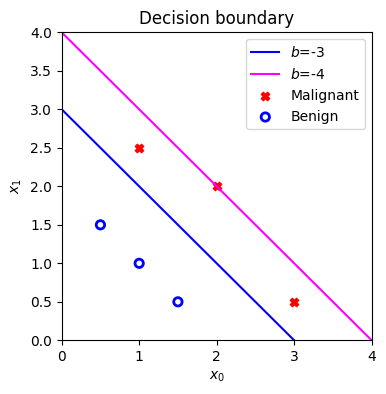

In [107]:
fig,ax = plt.subplots(1, 1, figsize=(4,4))

x0 = np.arange(0,6)
 
x1 = 3 - x0
x1_other = 4 - x0
ax.plot(x0, x1, c='blue', label="$b$=-3")
ax.plot(x0, x1_other, c='magenta', label="$b$=-4")
ax.axis([0,4,0,4])

plot_data(X_train, y_train, ax)
ax.set_xlabel('$x_0$')  
ax.set_ylabel('$x_1$')
ax.set_title("Decision boundary")
plt.show()

## Compare Cost for Two Bias Values

Lower cost indicates the decision boundary fits the training data better.
The bias value with lower cost places the boundary more correctly.

In [108]:
w_tmp=np.array([1,1])
b_1=-3
b_2=-4
print(compute_logistic_cost(X_train, y_train, w_tmp, b_1))
print(compute_logistic_cost(X_train, y_train, w_tmp, b_2))

0.36686678640551745
0.5036808636748461


## Gradient of Logistic Cost

Same structure as linear regression gradient —
only the prediction function changes from wx+b to sigmoid(wx+b).
Gradient descent algorithm itself is identical.

In [109]:
def compute_gradient_logistic(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X,w)+b
    g = sigmoid(z)
    err = (g - y)
    dj_dw = X.T @ err
    dj_dw = dj_dw/m
    dj_db = err.mean()
    return dj_dw, dj_db

## Gradient Descent — Logistic Regression

Reusing the same gradient descent structure from linear regression.
Cost and gradient functions are specific to logistic regression
but the optimisation loop is identical.

In [110]:
def gradient_descent(X, y, w_in, b_in, alpha, n_iters):

    w = copy.deepcopy(w_in)
    b = b_in
    j_history =[]

    for i in range(n_iters):

        dj_dw , dj_db = compute_gradient_logistic(X, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<100000:
            j_history.append(compute_logistic_cost(X, y, w, b))

        if i%math.ceil(n_iters/10)==0:
            print(f"Iteration {i:8d}: cost={j_history[-1]}")

    return w, b

    

## Train the Model

Initialise w to zeros and b to zero.
Run gradient descent and observe cost decreasing toward convergence.

In [111]:
w_tmp = np.zeros_like(X_train[0])
b_tmp = 0
alpha = 1e-1
iterations = 10000

w_final, b_final = gradient_descent(X_train, y_train, w_tmp, b_tmp, alpha, iterations)
print(f"\nLearned parameters: w={w_final}, b={b_final}")

Iteration        0: cost=0.684610468560574
Iteration     1000: cost=0.1590977666870456
Iteration     2000: cost=0.08460064176930084
Iteration     3000: cost=0.05705327279402528
Iteration     4000: cost=0.04290759421682
Iteration     5000: cost=0.03433847729884565
Iteration     6000: cost=0.02860379802212006
Iteration     7000: cost=0.02450156960879306
Iteration     8000: cost=0.02142370332569289
Iteration     9000: cost=0.019030137124109094

Learned parameters: w=[5.28123029 5.07815608], b=-14.222409982019839


## Plot Learned Decision Boundary

Draw the boundary learned by gradient descent.
Should cleanly separate malignant from benign training examples.

Text(0.5, 1.0, 'Decision boundary')

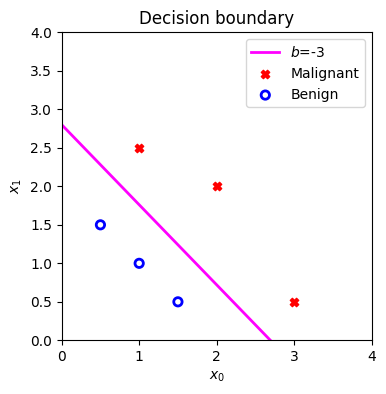

In [112]:
fig,ax = plt.subplots(1, 1, figsize=(4,4))

X0 = -b_final/w_final[0]
X1 = -b_final/w_final[1]
 
ax.plot([0, X0], [X1, 0], c='magenta', label="$b$=-3", lw=2)
ax.axis([0,4,0,4])

plot_data(X_train, y_train, ax)
ax.set_xlabel('$x_0$')  
ax.set_ylabel('$x_1$')
ax.set_title("Decision boundary")

## Predict on New Data

Pass new tumour measurements through the trained model.
Output is probability of malignancy — not a hard 0 or 1.
Threshold at 0.5: above means predicted malignant.

In [113]:
X_new = [2,1]
result = sigmoid(np.dot(X_new, w_final)+b_final)
print(f"X_new is {result*100:.2f}% likely to be malignant")

X_new is 80.51% likely to be malignant
